## DATA PROCESSING

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder

# 設定
DATA_DIR = "data"

In [2]:
# 讀取數據
print(f"Reading: {DATA_DIR}/train.csv {DATA_DIR}/test.csv")
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"Train shape: {train.shape}  Test shape: {test.shape}")
train.head()

Reading: data/train.csv data/test.csv
Train shape: (97992, 21)  Test shape: (3084, 20)


,rally_uid,sex,match,numberGame,rally_id,strickNumber,scoreSelf,scoreOther,serverGetPoint,gamePlayerId,...,serveId,serveNumber,strickId,handId,strengthId,spinId,pointId,actionId,let,positionId
0,1,1,1,1,1,1,0,0,1,1,...,1,0,1,1,3,5,4,0,0,0
1,1,1,1,1,1,2,0,0,1,2,...,1,1,2,2,2,1,9,4,0,0
2,1,1,1,1,1,3,0,0,1,1,...,1,1,4,1,1,1,7,1,0,0
3,1,1,1,1,1,4,0,0,1,2,...,1,1,4,0,0,0,0,0,0,0
4,1,1,1,1,1,5,0,0,1,1,...,1,1,-1,-1,-1,-1,-1,-1,-1,-1


In [3]:
# ============ 創建基礎特徵 ============
print("\n🔧 創建基礎特徵...")

for df, name in [(train, 'train'), (test, 'test')]:
    # rally_uid（唯一識別符）
    if 'rally_uid' not in df.columns:
        df['rally_uid'] = df['match'].astype(str) + '_' + df['rally_id'].astype(str)
    
    # match_id
    if 'match_id' not in df.columns:
        df['match_id'] = df['match']
    
    # stroke_number（當前是第幾拍）
    if 'stroke_number' not in df.columns and 'strickNumber' in df.columns:
        df['stroke_number'] = df['strickNumber']
    
    print(f"{name}: {df.shape}")

print("✅ 基礎特徵完成")


🔧 創建基礎特徵...
train: (97992, 23)
test: (3084, 22)
✅ 基礎特徵完成


In [4]:
# ============ 創建標籤（next_actionId, next_pointId）============
print("\n🎯 創建標籤...")

# 為訓練集創建標籤
train['next_actionId'] = train.groupby('rally_id')['actionId'].shift(-1)
train['next_pointId'] = train.groupby('rally_id')['pointId'].shift(-1)

# 處理最後一拍（下一拍是結束）
train['next_actionId'] = train['next_actionId'].fillna(-1).astype(int)
train['next_pointId'] = train['next_pointId'].fillna(-1).astype(int)

print(f"標籤統計:")
print(f"  next_actionId: {train['next_actionId'].value_counts().sort_index()}")
print(f"  next_pointId: {train['next_pointId'].value_counts().sort_index()}")


🎯 創建標籤...
標籤統計:
  next_actionId: next_actionId
-1     15450
 0      6759
 1     14993
 2      6546
 3      1709
 4      2878
 5      4108
 6      6583
 7      1476
 8       200
 9       425
 10     9925
 11     4118
 12     3752
 13     7815
 14      569
 15     8216
 16     1685
 17      526
 18      259
Name: count, dtype: int64
  next_pointId: next_pointId
-1    15450
 0     7724
 1     2677
 2     6243
 3      956
 4     4674
 5     8987
 6     5168
 7    10669
 8    14915
 9    20529
Name: count, dtype: int64


In [5]:
# ============ 基礎特徵工程 ============
print("\n🔧 基礎特徵工程...")

for df, name in [(train, 'train'), (test, 'test')]:
    print(f"\n處理 {name}...")
    
    # 前 1 拍的特徵
    for col in ['actionId', 'pointId', 'handId', 'strengthId', 'spinId']:
        if col in df.columns:
            df[f'prev1_{col}'] = df.groupby('rally_id')[col].shift(1).fillna(-1).astype(int)
    
    # 比分特徵
    if 'scoreSelf' in df.columns and 'scoreOther' in df.columns:
        df['score_diff'] = df['scoreSelf'] - df['scoreOther']
        df['score_sum'] = df['scoreSelf'] + df['scoreOther']
        df['is_leading'] = (df['score_diff'] > 0).astype(int)
    
    # 是否是發球局得分（如果有這個欄位）
    if 'serverGetPoint' in df.columns:
        df['server_won_point'] = df['serverGetPoint']

print("✅ 基礎特徵完成")


🔧 基礎特徵工程...

處理 train...

處理 test...
✅ 基礎特徵完成


In [6]:
# ============ 清理數據 ============
print("\n🧹 清理數據...")
print(f"清理前 train shape: {train.shape}")

# 複製用於清理
clean_train = train.copy()
clean_test = test.copy()

# 步驟1: 移除「當前拍」是結束拍的樣本
if 'actionId' in clean_train.columns:
    before_len = len(clean_train)
    clean_train = clean_train[clean_train['actionId'] != -1].copy()
    removed = before_len - len(clean_train)
    print(f"\n🔧 步驟1：移除當前拍是結束拍的樣本...")
    print(f"   移除 actionId = -1: {removed} 行 ({removed/before_len*100:.1f}%)")

# 步驟2: 移除標籤為 NaN 的樣本
if 'next_actionId' in clean_train.columns:
    before_len = len(clean_train)
    clean_train = clean_train.dropna(subset=['next_actionId', 'next_pointId']).copy()
    removed = before_len - len(clean_train)
    print(f"\n🔧 步驟2：移除標籤為 NaN 的樣本...")
    print(f"   移除 NaN 標籤: {removed} 行")

# 檢查標籤
print(f"\n✅ 最終標籤統計:")
if 'next_actionId' in clean_train.columns:
    print(f"   next_actionId:")
    print(f"     類別數: {clean_train['next_actionId'].nunique()}")
    print(f"     範圍: [{clean_train['next_actionId'].min()}, {clean_train['next_actionId'].max()}]")
    neg1_count = (clean_train['next_actionId'] == -1).sum()
    print(f"     包含 -1: {neg1_count} 筆 ({neg1_count/len(clean_train)*100:.1f}%) ← 預測下一拍是結束拍")

print(f"\n清理後 train shape: {clean_train.shape}")


🧹 清理數據...
清理前 train shape: (97992, 34)

🔧 步驟1：移除當前拍是結束拍的樣本...
   移除 actionId = -1: 15420 行 (15.7%)



🔧 步驟2：移除標籤為 NaN 的樣本...
   移除 NaN 標籤: 0 行

✅ 最終標籤統計:
   next_actionId:
     類別數: 20
     範圍: [-1, 18]
     包含 -1: 15420 筆 (18.7%) ← 預測下一拍是結束拍

清理後 train shape: (82572, 34)


In [7]:
# ============================================================
# 🆕 添加強力特徵以提升 LB（修正版 - 全部數值型）
# ============================================================
print("\n" + "="*60)
print("🆕 添加強力特徵")
print("="*60)

from sklearn.preprocessing import LabelEncoder

# 處理訓練集和測試集
for df, name in [(clean_train, '訓練'), (clean_test, '測試')]:
    print(f"\n處理 {name} 集...")
    original_cols = len(df.columns)
    
    # ===== 特徵組 1: 歷史序列特徵 =====
    print("  添加歷史序列特徵...")
    
    # 前 2-4 拍的特徵
    for k in range(2, 5):
        for col in ['actionId', 'pointId', 'handId', 'strengthId', 'spinId']:
            if col in df.columns:
                df[f'prev{k}_{col}'] = df.groupby('rally_id')[col].shift(k).fillna(-1).astype(int)
    
    # 動作序列模式（數值編碼）
    if 'actionId' in df.columns:
        df['action_prev1'] = df.groupby('rally_id')['actionId'].shift(1).fillna(-1).astype(int)
        df['action_prev2'] = df.groupby('rally_id')['actionId'].shift(2).fillna(-1).astype(int)
        # 數值組合（不是字符串！）
        df['action_seq_numeric'] = (
            df['action_prev1'] * 100 + df['action_prev2'] * 10 + df['actionId']
        )
    
    # ===== 特徵組 2: 落點變化 =====
    print("  添加落點變化特徵...")
    
    if 'pointId' in df.columns:
        df['point_prev1'] = df.groupby('rally_id')['pointId'].shift(1).fillna(-1).astype(int)
        df['point_change'] = df['pointId'] - df['point_prev1']
        df['point_change'] = df['point_change'].fillna(0)
        
        # 落點變化方向
        df['point_direction'] = 0
        df.loc[df['point_change'] > 0, 'point_direction'] = 1
        df.loc[df['point_change'] < 0, 'point_direction'] = -1
        
        # 落點變化幅度
        df['point_change_abs'] = abs(df['point_change'])
    
    # ===== 特徵組 3: 回合階段 =====
    print("  添加回合階段特徵...")
    
    if 'stroke_number' in df.columns:
        # 回合階段
        df['stroke_phase'] = 0
        df.loc[df['stroke_number'] <= 2, 'stroke_phase'] = 1  # 開局
        df.loc[(df['stroke_number'] >= 3) & (df['stroke_number'] <= 4), 'stroke_phase'] = 2  # 中期
        df.loc[df['stroke_number'] >= 5, 'stroke_phase'] = 3  # 後期
        
        # 是否早期拍
        df['is_early_rally'] = (df['stroke_number'] <= 3).astype(int)
        df['is_mid_rally'] = ((df['stroke_number'] >= 4) & (df['stroke_number'] <= 6)).astype(int)
    
    # ===== 特徵組 4: 比分壓力 =====
    print("  添加比分壓力特徵...")
    
    if 'score_diff' in df.columns:
        # 比分壓力等級
        df['score_pressure'] = 0
        df.loc[df['score_diff'] <= -3, 'score_pressure'] = 3
        df.loc[df['score_diff'] == -2, 'score_pressure'] = 2
        df.loc[df['score_diff'] == -1, 'score_pressure'] = 1
        df.loc[df['score_diff'] == 1, 'score_pressure'] = -1
        df.loc[df['score_diff'] == 2, 'score_pressure'] = -2
        df.loc[df['score_diff'] >= 3, 'score_pressure'] = -3
        
        # 是否關鍵分
        if 'scoreSelf' in df.columns and 'scoreOther' in df.columns:
            df['is_key_point'] = (
                ((df['scoreSelf'] >= 9) | (df['scoreOther'] >= 9)) & 
                (abs(df['score_diff']) <= 2)
            ).astype(int)
    
    # ===== 特徵組 5: 組合特徵（數值編碼）=====
    print("  添加組合特徵...")
    
    if 'handId' in df.columns and 'strengthId' in df.columns:
        df['hand_strength_encoded'] = df['handId'] * 10 + df['strengthId']
    
    if 'actionId' in df.columns and 'pointId' in df.columns:
        df['action_point_encoded'] = df['actionId'] * 10 + df['pointId']
    
    # ===== 特徵組 6: 動作持續性 =====
    print("  添加動作持續性特徵...")
    
    if 'actionId' in df.columns:
        df['action_same_as_prev'] = (
            df['actionId'] == df.groupby('rally_id')['actionId'].shift(1)
        ).astype(int)
    
    if 'pointId' in df.columns:
        df['point_same_as_prev'] = (
            df['pointId'] == df.groupby('rally_id')['pointId'].shift(1)
        ).astype(int)
    
    # ===== 特徵組 7: 統計特徵 =====
    print("  添加統計特徵...")
    
    if 'actionId' in df.columns:
        df['action_diversity'] = (
            df.groupby('rally_id')['actionId']
            .transform(lambda x: x.expanding().apply(lambda y: len(set(y))))
        )
    
    # 更新 dataframe
    if name == '訓練':
        clean_train = df
    else:
        clean_test = df
    
    new_cols = len(df.columns)
    print(f"  ✅ 添加了 {new_cols - original_cols} 個新特徵")

print(f"\n✅ 特徵工程完成！")
print(f"訓練集最終大小: {clean_train.shape}")
print(f"測試集最終大小: {clean_test.shape}")


🆕 添加強力特徵

處理 訓練 集...
  添加歷史序列特徵...
  添加落點變化特徵...
  添加回合階段特徵...
  添加比分壓力特徵...
  添加組合特徵...
  添加動作持續性特徵...
  添加統計特徵...
  ✅ 添加了 32 個新特徵

處理 測試 集...
  添加歷史序列特徵...
  添加落點變化特徵...
  添加回合階段特徵...
  添加比分壓力特徵...
  添加組合特徵...
  添加動作持續性特徵...
  添加統計特徵...
  ✅ 添加了 32 個新特徵

✅ 特徵工程完成！
訓練集最終大小: (82572, 66)
測試集最終大小: (3084, 62)


In [8]:
# ============ 填充缺失值 ============
print("\n🔧 填充缺失值...")

for df, name in [(clean_train, 'train'), (clean_test, 'test')]:
    for col in df.columns:
        if df[col].isna().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                fill_value = df[col].median()
                df[col] = df[col].fillna(fill_value)
    
    if name == 'train':
        clean_train = df
    else:
        clean_test = df

print("✅ 缺失值處理完成")

# 檢查 object 類型
print("\n🔍 檢查數據類型...")
object_cols_train = clean_train.select_dtypes(include=['object']).columns.tolist()
allowed_object_cols = ['match', 'match_id', 'rally_uid', 'rally_id', 
                       'next_actionId', 'next_pointId', 'serverGetPoint', 
                       'server_won_point', 'actionId', 'pointId']
problem_cols = [c for c in object_cols_train if c not in allowed_object_cols]

if problem_cols:
    print(f"⚠️  移除 object 類型欄位: {problem_cols}")
    clean_train = clean_train.drop(columns=problem_cols)
    clean_test = clean_test.drop(columns=[c for c in problem_cols if c in clean_test.columns])
else:
    print("✅ 沒有問題的 object 類型欄位")

# 移除常數特徵
const_features = [col for col in clean_train.columns 
                  if clean_train[col].nunique() == 1]
if const_features:
    print(f"\n🗑️ 移除 {len(const_features)} 個常數特徵: {const_features}")
    clean_train = clean_train.drop(columns=const_features)
    clean_test = clean_test.drop(columns=[c for c in const_features if c in clean_test.columns])

print(f"\n✅ 處理完成！")
print(f"clean_train: {clean_train.shape}")
print(f"clean_test: {clean_test.shape}")


🔧 填充缺失值...
✅ 缺失值處理完成

🔍 檢查數據類型...
✅ 沒有問題的 object 類型欄位

✅ 處理完成！
clean_train: (82572, 66)
clean_test: (3084, 62)


In [9]:
# ============================================================
# 🚨 緊急：只保留絕對安全的特徵
# ============================================================
print("\n" + "="*60)
print("🚨 緊急模式：移除可疑特徵")
print("="*60)

# 定義絕對安全的特徵
safe_features = [
    # ID
    'rally_uid', 'match_id', 'rally_id', 'stroke_number',
    
    # 當前拍
    'actionId', 'pointId', 'handId', 'strengthId', 'spinId',
    
    # 前 1-2 拍
    'prev1_actionId', 'prev1_pointId', 'prev1_handId', 'prev1_strengthId', 'prev1_spinId',
    'prev2_actionId', 'prev2_pointId', 'prev2_handId', 'prev2_strengthId', 'prev2_spinId',
    
    # 比分
    'scoreSelf', 'scoreOther', 'score_diff', 'score_sum', 'is_leading',
    
    # 組合
    'hand_strength_encoded', 'action_point_encoded',
    
    # 階段
    'is_early_rally', 'stroke_phase',
    
    # 標籤
    'next_actionId', 'next_pointId', 'serverGetPoint', 'server_won_point',
]

# 過濾特徵
print(f"\n原始特徵數: {len(clean_train.columns)}")
removed_features = [c for c in clean_train.columns if c not in safe_features]
print(f"移除的特徵: {removed_features}")

clean_train = clean_train[[c for c in safe_features if c in clean_train.columns]].copy()
clean_test = clean_test[[c for c in safe_features if c in clean_test.columns]].copy()

print(f"安全特徵數: {len(clean_train.columns)}")
print("✅ 已移除可疑特徵")


🚨 緊急模式：移除可疑特徵

原始特徵數: 66
移除的特徵: ['sex', 'match', 'numberGame', 'strickNumber', 'gamePlayerId', 'gamePlayerOtherId', 'serveId', 'serveNumber', 'strickId', 'let', 'positionId', 'prev3_actionId', 'prev3_pointId', 'prev3_handId', 'prev3_strengthId', 'prev3_spinId', 'prev4_actionId', 'prev4_pointId', 'prev4_handId', 'prev4_strengthId', 'prev4_spinId', 'action_prev1', 'action_prev2', 'action_seq_numeric', 'point_prev1', 'point_change', 'point_direction', 'point_change_abs', 'is_mid_rally', 'score_pressure', 'is_key_point', 'action_same_as_prev', 'point_same_as_prev', 'action_diversity']
安全特徵數: 32
✅ 已移除可疑特徵


In [10]:
# ============================================================
# 🚀 一次添加所有 7 個特徵交互（一步到位版本）
# 替換你剛才添加的那個 Cell，或在保存 CSV 之前插入
# ============================================================

print("\n" + "="*60)
print("🚀 一次添加所有特徵交互")
print("="*60)

from sklearn.preprocessing import LabelEncoder

# ============================================================
# 特徵 1：前一拍動作-落點組合 ⭐⭐⭐⭐⭐
# ============================================================
print("\n創建特徵 1/7: prev1_action_point...")

if 'prev1_actionId' in clean_train.columns and 'prev1_pointId' in clean_train.columns:
    # 訓練集
    clean_train['prev1_action_point_str'] = (
        clean_train['prev1_actionId'].fillna(-99).astype(int).astype(str) + '_' + 
        clean_train['prev1_pointId'].fillna(-99).astype(int).astype(str)
    )
    
    # 測試集
    clean_test['prev1_action_point_str'] = (
        clean_test['prev1_actionId'].fillna(-99).astype(int).astype(str) + '_' + 
        clean_test['prev1_pointId'].fillna(-99).astype(int).astype(str)
    )
    
    # 訓練集 fit
    le1 = LabelEncoder()
    clean_train['prev1_action_point'] = le1.fit_transform(clean_train['prev1_action_point_str'])
    
    # 測試集 transform
    clean_test['prev1_action_point'] = clean_test['prev1_action_point_str'].map(
        lambda x: le1.transform([x])[0] if x in le1.classes_ else -1
    )
    
    # 刪除臨時列
    clean_train = clean_train.drop(columns=['prev1_action_point_str'])
    clean_test = clean_test.drop(columns=['prev1_action_point_str'])
    
    print(f"  ✅ 訓練集: {clean_train['prev1_action_point'].nunique()} 個組合")
    print(f"  ✅ 測試集: {clean_test['prev1_action_point'].nunique()} 個組合")

# ============================================================
# 特徵 2：當前動作-落點組合 ⭐⭐⭐⭐⭐
# ============================================================
print("\n創建特徵 2/7: curr_action_point...")

if 'actionId' in clean_train.columns and 'pointId' in clean_train.columns:
    # 訓練集
    clean_train['curr_action_point_str'] = (
        clean_train['actionId'].fillna(-99).astype(int).astype(str) + '_' + 
        clean_train['pointId'].fillna(-99).astype(int).astype(str)
    )
    
    # 測試集
    clean_test['curr_action_point_str'] = (
        clean_test['actionId'].fillna(-99).astype(int).astype(str) + '_' + 
        clean_test['pointId'].fillna(-99).astype(int).astype(str)
    )
    
    # 訓練集 fit
    le2 = LabelEncoder()
    clean_train['curr_action_point'] = le2.fit_transform(clean_train['curr_action_point_str'])
    
    # 測試集 transform
    clean_test['curr_action_point'] = clean_test['curr_action_point_str'].map(
        lambda x: le2.transform([x])[0] if x in le2.classes_ else -1
    )
    
    # 刪除臨時列
    clean_train = clean_train.drop(columns=['curr_action_point_str'])
    clean_test = clean_test.drop(columns=['curr_action_point_str'])
    
    print(f"  ✅ 訓練集: {clean_train['curr_action_point'].nunique()} 個組合")
    print(f"  ✅ 測試集: {clean_test['curr_action_point'].nunique()} 個組合")

# ============================================================
# 特徵 3：動作轉換模式 ⭐⭐⭐⭐
# ============================================================
print("\n創建特徵 3/7: action_transition...")

if 'prev1_actionId' in clean_train.columns and 'actionId' in clean_train.columns:
    # 訓練集
    clean_train['action_transition_str'] = (
        clean_train['prev1_actionId'].fillna(-99).astype(int).astype(str) + '_to_' + 
        clean_train['actionId'].fillna(-99).astype(int).astype(str)
    )
    
    # 測試集
    clean_test['action_transition_str'] = (
        clean_test['prev1_actionId'].fillna(-99).astype(int).astype(str) + '_to_' + 
        clean_test['actionId'].fillna(-99).astype(int).astype(str)
    )
    
    # 訓練集 fit
    le3 = LabelEncoder()
    clean_train['action_transition'] = le3.fit_transform(clean_train['action_transition_str'])
    
    # 測試集 transform
    clean_test['action_transition'] = clean_test['action_transition_str'].map(
        lambda x: le3.transform([x])[0] if x in le3.classes_ else -1
    )
    
    # 刪除臨時列
    clean_train = clean_train.drop(columns=['action_transition_str'])
    clean_test = clean_test.drop(columns=['action_transition_str'])
    
    print(f"  ✅ 訓練集: {clean_train['action_transition'].nunique()} 個轉換")
    print(f"  ✅ 測試集: {clean_test['action_transition'].nunique()} 個轉換")

# ============================================================
# 特徵 4：落點轉換模式 ⭐⭐⭐⭐
# ============================================================
print("\n創建特徵 4/7: point_transition...")

if 'prev1_pointId' in clean_train.columns and 'pointId' in clean_train.columns:
    # 訓練集
    clean_train['point_transition_str'] = (
        clean_train['prev1_pointId'].fillna(-99).astype(int).astype(str) + '_to_' + 
        clean_train['pointId'].fillna(-99).astype(int).astype(str)
    )
    
    # 測試集
    clean_test['point_transition_str'] = (
        clean_test['prev1_pointId'].fillna(-99).astype(int).astype(str) + '_to_' + 
        clean_test['pointId'].fillna(-99).astype(int).astype(str)
    )
    
    # 訓練集 fit
    le4 = LabelEncoder()
    clean_train['point_transition'] = le4.fit_transform(clean_train['point_transition_str'])
    
    # 測試集 transform
    clean_test['point_transition'] = clean_test['point_transition_str'].map(
        lambda x: le4.transform([x])[0] if x in le4.classes_ else -1
    )
    
    # 刪除臨時列
    clean_train = clean_train.drop(columns=['point_transition_str'])
    clean_test = clean_test.drop(columns=['point_transition_str'])
    
    print(f"  ✅ 訓練集: {clean_train['point_transition'].nunique()} 個轉換")
    print(f"  ✅ 測試集: {clean_test['point_transition'].nunique()} 個轉換")

# ============================================================
# 特徵 5：手部-落點組合 ⭐⭐⭐
# ============================================================
print("\n創建特徵 5/7: hand_point...")

if 'handId' in clean_train.columns and 'pointId' in clean_train.columns:
    # 訓練集
    clean_train['hand_point_str'] = (
        clean_train['handId'].fillna(-99).astype(int).astype(str) + '_' + 
        clean_train['pointId'].fillna(-99).astype(int).astype(str)
    )
    
    # 測試集
    clean_test['hand_point_str'] = (
        clean_test['handId'].fillna(-99).astype(int).astype(str) + '_' + 
        clean_test['pointId'].fillna(-99).astype(int).astype(str)
    )
    
    # 訓練集 fit
    le5 = LabelEncoder()
    clean_train['hand_point'] = le5.fit_transform(clean_train['hand_point_str'])
    
    # 測試集 transform
    clean_test['hand_point'] = clean_test['hand_point_str'].map(
        lambda x: le5.transform([x])[0] if x in le5.classes_ else -1
    )
    
    # 刪除臨時列
    clean_train = clean_train.drop(columns=['hand_point_str'])
    clean_test = clean_test.drop(columns=['hand_point_str'])
    
    print(f"  ✅ 訓練集: {clean_train['hand_point'].nunique()} 個組合")
    print(f"  ✅ 測試集: {clean_test['hand_point'].nunique()} 個組合")

# ============================================================
# 特徵 6：比分階段 ⭐⭐⭐
# ============================================================
print("\n創建特徵 6/7: score_phase...")

if 'scoreSelf' in clean_train.columns and 'scoreOther' in clean_train.columns:
    # 訓練集
    clean_train['score_phase_str'] = (
        clean_train['scoreSelf'].astype(str) + '_' + 
        clean_train['scoreOther'].astype(str)
    )
    
    # 測試集
    clean_test['score_phase_str'] = (
        clean_test['scoreSelf'].astype(str) + '_' + 
        clean_test['scoreOther'].astype(str)
    )
    
    # 訓練集 fit
    le6 = LabelEncoder()
    clean_train['score_phase'] = le6.fit_transform(clean_train['score_phase_str'])
    
    # 測試集 transform
    clean_test['score_phase'] = clean_test['score_phase_str'].map(
        lambda x: le6.transform([x])[0] if x in le6.classes_ else -1
    )
    
    # 刪除臨時列
    clean_train = clean_train.drop(columns=['score_phase_str'])
    clean_test = clean_test.drop(columns=['score_phase_str'])
    
    print(f"  ✅ 訓練集: {clean_train['score_phase'].nunique()} 個階段")
    print(f"  ✅ 測試集: {clean_test['score_phase'].nunique()} 個階段")

# ============================================================
# 特徵 7：連續 3 拍動作序列 ⭐⭐⭐⭐
# ============================================================
print("\n創建特徵 7/7: action_seq_3...")

if all(f in clean_train.columns for f in ['prev2_actionId', 'prev1_actionId', 'actionId']):
    # 訓練集
    clean_train['action_seq_3_str'] = (
        clean_train['prev2_actionId'].fillna(-99).astype(int).astype(str) + '_' +
        clean_train['prev1_actionId'].fillna(-99).astype(int).astype(str) + '_' +
        clean_train['actionId'].fillna(-99).astype(int).astype(str)
    )
    
    # 測試集
    clean_test['action_seq_3_str'] = (
        clean_test['prev2_actionId'].fillna(-99).astype(int).astype(str) + '_' +
        clean_test['prev1_actionId'].fillna(-99).astype(int).astype(str) + '_' +
        clean_test['actionId'].fillna(-99).astype(int).astype(str)
    )
    
    # 訓練集 fit
    le7 = LabelEncoder()
    clean_train['action_seq_3'] = le7.fit_transform(clean_train['action_seq_3_str'])
    
    # 測試集 transform
    clean_test['action_seq_3'] = clean_test['action_seq_3_str'].map(
        lambda x: le7.transform([x])[0] if x in le7.classes_ else -1
    )
    
    # 刪除臨時列
    clean_train = clean_train.drop(columns=['action_seq_3_str'])
    clean_test = clean_test.drop(columns=['action_seq_3_str'])
    
    print(f"  ✅ 訓練集: {clean_train['action_seq_3'].nunique()} 個序列")
    print(f"  ✅ 測試集: {clean_test['action_seq_3'].nunique()} 個序列")

# ============================================================
# 總結
# ============================================================
print("\n" + "="*60)
print("✅ 所有特徵創建完成")
print("="*60)

new_features = [
    'prev1_action_point',
    'curr_action_point',
    'action_transition',
    'point_transition',
    'hand_point',
    'score_phase',
    'action_seq_3',
]

print(f"\n新增特徵檢查:")
for f in new_features:
    in_train = f in clean_train.columns
    in_test = f in clean_test.columns
    status = '✅' if (in_train and in_test) else '❌'
    print(f"  {status} {f}")

print(f"\n最終 DataFrame shape:")
print(f"  clean_train: {clean_train.shape}  ← 應該是 (82572, 74)")
print(f"  clean_test: {clean_test.shape}   ← 應該是 (3084, 70)")

print("\n" + "="*60)
print("🚀 下一步：運行保存 CSV 的 Cell，然後重新訓練 LightGBM")
print("="*60)


🚀 一次添加所有特徵交互

創建特徵 1/7: prev1_action_point...
  ✅ 訓練集: 175 個組合
  ✅ 測試集: 141 個組合

創建特徵 2/7: curr_action_point...
  ✅ 訓練集: 188 個組合
  ✅ 測試集: 147 個組合

創建特徵 3/7: action_transition...
  ✅ 訓練集: 277 個轉換
  ✅ 測試集: 178 個轉換

創建特徵 4/7: point_transition...
  ✅ 訓練集: 109 個轉換
  ✅ 測試集: 103 個轉換

創建特徵 5/7: hand_point...
  ✅ 訓練集: 30 個組合
  ✅ 測試集: 22 個組合

創建特徵 6/7: score_phase...
  ✅ 訓練集: 150 個階段
  ✅ 測試集: 53 個階段

創建特徵 7/7: action_seq_3...
  ✅ 訓練集: 2252 個序列
  ✅ 測試集: 697 個序列

✅ 所有特徵創建完成

新增特徵檢查:
  ✅ prev1_action_point
  ✅ curr_action_point
  ✅ action_transition
  ✅ point_transition
  ✅ hand_point
  ✅ score_phase
  ✅ action_seq_3

最終 DataFrame shape:
  clean_train: (82572, 39)  ← 應該是 (82572, 74)
  clean_test: (3084, 35)   ← 應該是 (3084, 70)

🚀 下一步：運行保存 CSV 的 Cell，然後重新訓練 LightGBM


In [11]:
# ============ 保存文件 ============
print("\n💾 保存文件...")

# 輸出
clean_train.to_csv(f"{DATA_DIR}/clean_train_v2.csv", index=False)
clean_test.to_csv(f"{DATA_DIR}/clean_test_v2.csv", index=False)

print(f"✅ 已保存: clean_train_v2.csv, clean_test_v2.csv")
print(f"\n最終形狀:")
print(f"  訓練集: {clean_train.shape}")
print(f"  測試集: {clean_test.shape}")
print(f"\n可用特徵數: {len([c for c in clean_train.columns if c not in ['match_id', 'rally_id', 'rally_uid', 'next_actionId', 'next_pointId', 'serverGetPoint', 'server_won_point', 'actionId', 'pointId']])}")


💾 保存文件...
✅ 已保存: clean_train_v2.csv, clean_test_v2.csv

最終形狀:
  訓練集: (82572, 39)
  測試集: (3084, 35)

可用特徵數: 30


## EDA

In [12]:
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Taipei Sans TC Beta', 'Noto Sans CJK TC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 讓負號正常顯示

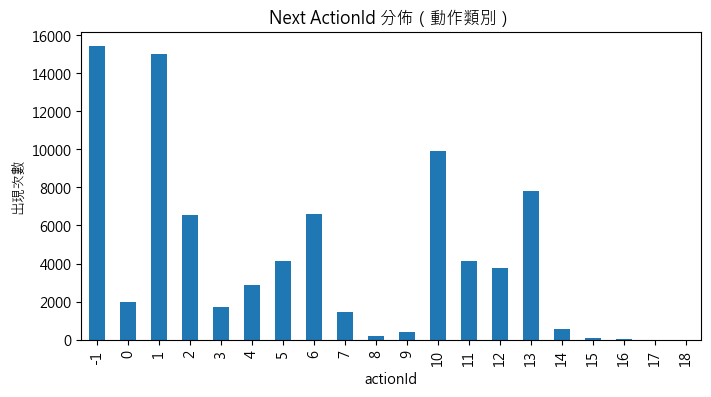

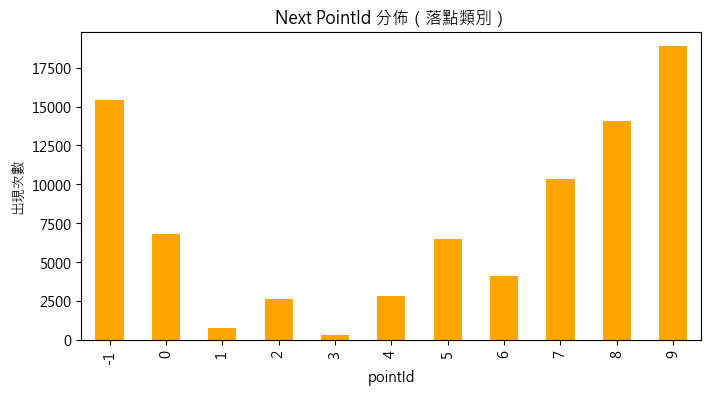

In [13]:
# 1️⃣ Next ActionId 分佈
if "next_actionId" in clean_train.columns:
    plt.figure(figsize=(8,4))
    clean_train["next_actionId"].value_counts().sort_index().plot(kind="bar")
    plt.title("Next ActionId 分佈（動作類別）")
    plt.xlabel("actionId")
    plt.ylabel("出現次數")
    plt.show()

# 2️⃣ Next PointId 分佈
if "next_pointId" in clean_train.columns:
    plt.figure(figsize=(8,4))
    clean_train["next_pointId"].value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title("Next PointId 分佈（落點類別）")
    plt.xlabel("pointId")
    plt.ylabel("出現次數")
    plt.show()

# 3️⃣ Rally 長度分佈
if "rally_length" in clean_train.columns:
    plt.figure(figsize=(6,4))
    clean_train["rally_length"].hist(bins=30)
    plt.title("Rally 長度分佈")
    plt.xlabel("單回合擊球次數")
    plt.ylabel("回合數")
    plt.show()

# 4️⃣ 不同回合階段的動作比例
if "rally_progress" in clean_train.columns and "next_actionId" in clean_train.columns:
    bins = pd.cut(clean_train["rally_progress"], bins=10)
    comp = clean_train.groupby(bins)["next_actionId"].value_counts(normalize=True).unstack().fillna(0)
    comp.plot(kind="bar", stacked=True, figsize=(10,5))
    plt.title("不同回合階段的動作比例")
    plt.ylabel("比例")
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'Taipei Sans TC Beta', 'Noto Sans CJK TC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 讓負號正常顯示

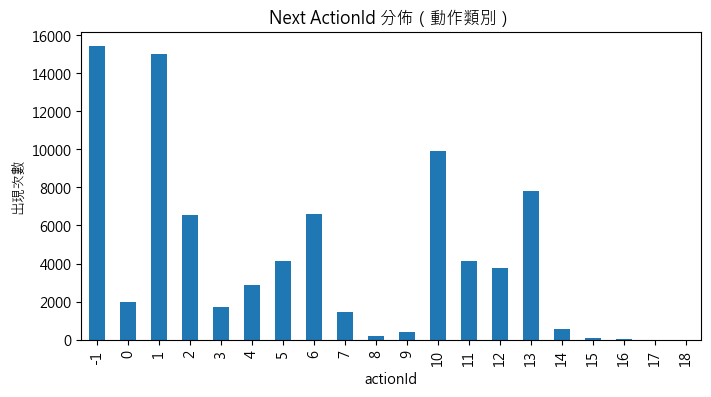

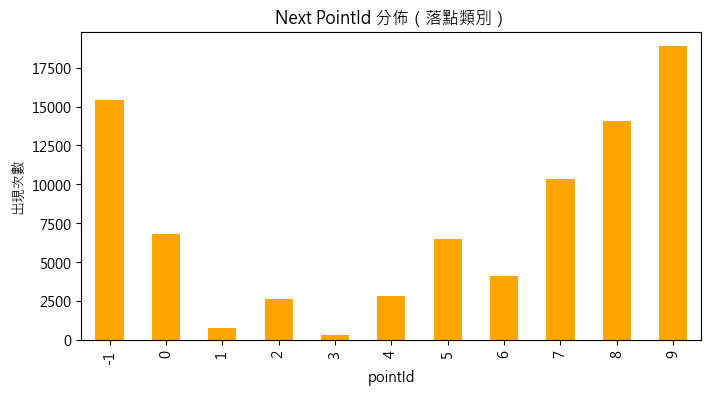

In [ ]:
# 1️⃣ Next ActionId 分佈
if "next_actionId" in clean_train.columns:
    plt.figure(figsize=(8,4))
    clean_train["next_actionId"].value_counts().sort_index().plot(kind="bar")
    plt.title("Next ActionId 分佈（動作類別）")
    plt.xlabel("actionId")
    plt.ylabel("出現次數")
    plt.show()

# 2️⃣ Next PointId 分佈
if "next_pointId" in clean_train.columns:
    plt.figure(figsize=(8,4))
    clean_train["next_pointId"].value_counts().sort_index().plot(kind="bar", color="orange")
    plt.title("Next PointId 分佈（落點類別）")
    plt.xlabel("pointId")
    plt.ylabel("出現次數")
    plt.show()

# 3️⃣ Rally 長度分佈
if "rally_length" in clean_train.columns:
    plt.figure(figsize=(6,4))
    clean_train["rally_length"].hist(bins=30)
    plt.title("Rally 長度分佈")
    plt.xlabel("單回合擊球次數")
    plt.ylabel("回合數")
    plt.show()

# 4️⃣ 不同回合階段的動作比例
if "rally_progress" in clean_train.columns and "next_actionId" in clean_train.columns:
    bins = pd.cut(clean_train["rally_progress"], bins=10)
    comp = clean_train.groupby(bins)["next_actionId"].value_counts(normalize=True).unstack().fillna(0)
    comp.plot(kind="bar", stacked=True, figsize=(10,5))
    plt.title("不同回合階段的動作比例")
    plt.ylabel("比例")
    plt.show()


In [ ]:
print("="*60)
print("📊 EDA 1: 回合長度分析")
print("="*60)

# 確保有 rally_uid 和 stroke_number
if 'rally_uid' not in train.columns:
    train['rally_uid'] = train['match'].astype(str) + '_' + train['rally_id'].astype(str)
    test['rally_uid'] = test['match'].astype(str) + '_' + test['rally_id'].astype(str)
if 'stroke_number' not in train.columns:
    train['stroke_number'] = train['strickNumber']
    test['stroke_number'] = test['strickNumber']

rally_lengths_train = train.groupby('rally_uid')['stroke_number'].max()
rally_lengths_test = test.groupby('rally_uid')['stroke_number'].max()

print(f"\n訓練集回合統計:")
print(f"  平均長度: {rally_lengths_train.mean():.2f} 拍")
print(f"  中位數:   {rally_lengths_train.median():.0f} 拍")

print(f"\n測試集回合統計:")
print(f"  平均長度: {rally_lengths_test.mean():.2f} 拍")
print(f"  中位數:   {rally_lengths_test.median():.0f} 拍")

print(f"\n回合長度分布 (Top 10):")
for length, count in rally_lengths_train.value_counts().sort_index().head(10).items():
    print(f"  {int(length):2d} 拍: {count:5d} 個 ({count/len(rally_lengths_train)*100:5.2f}%)")

print("\n" + "="*60)
print("💡 特徵工程決策:")
print("="*60)
print(f"✅ 中位數約 {rally_lengths_train.median():.0f} 拍")
print(f"✅ 使用 prev1-3 歷史特徵（足夠覆蓋大部分回合）")
print("="*60)

📊 EDA 1: 回合長度分析

訓練集回合統計:
  平均長度: 6.34 拍
  中位數:   5 拍

測試集回合統計:
  平均長度: 3.07 拍
  中位數:   2 拍

回合長度分布 (Top 10):
   1 拍:     2 個 ( 0.01%)
   2 拍:   872 個 ( 5.65%)
   3 拍:  1747 個 (11.32%)
   4 拍:  2541 個 (16.47%)
   5 拍:  2893 個 (18.75%)
   6 拍:  1979 個 (12.82%)
   7 拍:  1554 個 (10.07%)
   8 拍:  1011 個 ( 6.55%)
   9 拍:   782 個 ( 5.07%)
  10 拍:   509 個 ( 3.30%)

💡 特徵工程決策:
✅ 中位數約 5 拍
✅ 使用 prev1-3 歷史特徵（足夠覆蓋大部分回合）


In [ ]:
print("="*60)
print("📊 EDA 2: 動作-落點組合分析")
print("="*60)

# 只看有效樣本
train_valid = train[(train['actionId'] != -1) & (train['pointId'] != -1)].copy()
train_valid['action_point_combo'] = (
    train_valid['actionId'].astype(str) + '_' + 
    train_valid['pointId'].astype(str)
)

combo_dist = train_valid['action_point_combo'].value_counts().head(15)

print(f"\nTop 15 動作-落點組合:")
for i, (combo, count) in enumerate(combo_dist.items(), 1):
    action, point = combo.split('_')
    print(f"  {i:2d}. Action {action:2s} + Point {point:2s}: {count:6d} ({count/len(train_valid)*100:5.2f}%)")

print("\n" + "="*60)
print("💡 特徵工程決策:")
print("="*60)
print("✅ 某些動作通常配合特定落點")
print("✅ 創建 action_point 交互特徵（捕捉打法模式）")
print("="*60)

# 清理
del train_valid

📊 EDA 2: 動作-落點組合分析

Top 15 動作-落點組合:
   1. Action 1  + Point 9 :   5617 ( 6.80%)
   2. Action 1  + Point 8 :   3624 ( 4.39%)
   3. Action 1  + Point 7 :   3168 ( 3.84%)
   4. Action 0  + Point 0 :   2732 ( 3.31%)
   5. Action 6  + Point 9 :   2314 ( 2.80%)
   6. Action 15 + Point 2 :   2196 ( 2.66%)
   7. Action 10 + Point 9 :   2149 ( 2.60%)
   8. Action 13 + Point 8 :   2085 ( 2.53%)
   9. Action 10 + Point 6 :   2029 ( 2.46%)
  10. Action 13 + Point 9 :   1987 ( 2.41%)
  11. Action 2  + Point 9 :   1872 ( 2.27%)
  12. Action 6  + Point 8 :   1838 ( 2.23%)
  13. Action 10 + Point 5 :   1664 ( 2.02%)
  14. Action 5  + Point 9 :   1600 ( 1.94%)
  15. Action 10 + Point 8 :   1581 ( 1.91%)

💡 特徵工程決策:
✅ 某些動作通常配合特定落點
✅ 創建 action_point 交互特徵（捕捉打法模式）


In [ ]:
print("="*60)
print("📊 EDA 3: 動作轉換分析")
print("="*60)

train_trans = train.copy()
train_trans['prev_action'] = train_trans.groupby('rally_uid')['actionId'].shift(1)

# 只看有效轉換
valid_trans = train_trans[
    (train_trans['prev_action'].notna()) & 
    (train_trans['prev_action'] != -1) &
    (train_trans['actionId'] != -1)
].copy()

valid_trans['transition'] = (
    valid_trans['prev_action'].astype(int).astype(str) + ' → ' +
    valid_trans['actionId'].astype(int).astype(str)
)

trans_dist = valid_trans['transition'].value_counts().head(15)

print(f"\nTop 15 動作轉換:")
for i, (trans, count) in enumerate(trans_dist.items(), 1):
    print(f"  {i:2d}. {trans:10s}: {count:6d} ({count/len(valid_trans)*100:5.2f}%)")

print("\n" + "="*60)
print("💡 特徵工程決策:")
print("="*60)
print("✅ 動作轉換有明顯的偏好模式")
print("✅ 創建 action_transition 特徵（前一拍對下一拍有預測力）")
print("="*60)

# 清理
del train_trans, valid_trans

📊 EDA 3: 動作轉換分析

Top 15 動作轉換:
   1. 10 → 1    :   4395 ( 6.55%)
   2. 1 → 13    :   3962 ( 5.90%)
   3. 10 → 10   :   3350 ( 4.99%)
   4. 13 → 1    :   2516 ( 3.75%)
   5. 15 → 10   :   2502 ( 3.73%)
   6. 1 → 2     :   2172 ( 3.23%)
   7. 2 → 2     :   2032 ( 3.03%)
   8. 1 → 12    :   1997 ( 2.97%)
   9. 12 → 1    :   1814 ( 2.70%)
  10. 6 → 6     :   1679 ( 2.50%)
  11. 15 → 11   :   1609 ( 2.40%)
  12. 1 → 6     :   1609 ( 2.40%)
  13. 15 → 1    :   1494 ( 2.23%)
  14. 2 → 13    :   1379 ( 2.05%)
  15. 15 → 4    :   1363 ( 2.03%)

💡 特徵工程決策:
✅ 動作轉換有明顯的偏好模式
✅ 創建 action_transition 特徵（前一拍對下一拍有預測力）


In [ ]:
print("="*60)
print("📊 EDA 4: 比分影響分析")
print("="*60)

# 關鍵分 vs 一般分
game_points = train[(train['scoreSelf'] >= 10) | (train['scoreOther'] >= 10)]
normal_points = train[(train['scoreSelf'] < 10) & (train['scoreOther'] < 10)]

print(f"\n分數階段分布:")
print(f"  關鍵分 (≥10): {len(game_points):6d} ({len(game_points)/len(train)*100:5.2f}%)")
print(f"  一般分 (<10): {len(normal_points):6d} ({len(normal_points)/len(train)*100:5.2f}%)")

# 比較回合長度
if len(game_points) > 0 and len(normal_points) > 0:
    game_rally_len = game_points.groupby('rally_uid')['stroke_number'].max().mean()
    normal_rally_len = normal_points.groupby('rally_uid')['stroke_number'].max().mean()
    print(f"\n回合長度比較:")
    print(f"  關鍵分: {game_rally_len:.2f} 拍")
    print(f"  一般分: {normal_rally_len:.2f} 拍")
    print(f"  差異: {((game_rally_len/normal_rally_len-1)*100):+.1f}%")

print("\n" + "="*60)
print("💡 特徵工程決策:")
print("="*60)
print("✅ 比分影響選手策略")
print("✅ 創建 score_diff, is_game_point, score_phase 特徵")
print("="*60)

📊 EDA 4: 比分影響分析

分數階段分布:
  關鍵分 (≥10):  11551 (11.79%)
  一般分 (<10):  86441 (88.21%)

回合長度比較:
  關鍵分: 6.23 拍
  一般分: 6.36 拍
  差異: -1.9%

💡 特徵工程決策:
✅ 比分影響選手策略
✅ 創建 score_diff, is_game_point, score_phase 特徵
